# Customer Churn Prediction — Telco Dataset
### Python | scikit-learn | End-to-End Machine Learning Workflow

**Goal:** Predict which telecom customers are likely to churn (cancel their service), so the
business can act *before* they leave.

**Why it matters:** Acquiring a new customer costs 5–7x more than keeping an existing one.
If we can identify likely churners early, a small retention offer can save significant revenue.

**Workflow in this notebook:**
1. Load & understand the data
2. Clean the data
3. Exploratory Data Analysis (EDA)
4. Feature engineering
5. Preprocessing pipeline (no data leakage)
6. Train & compare 3 models — Logistic Regression, Decision Tree, Random Forest
7. Select the best model *for the business goal*
8. Feature importance
9. Export predictions for Power BI
10. Save the trained model

## A. Import Libraries

We use beginner-friendly, industry-standard libraries:
- **pandas / numpy** — data handling
- **matplotlib / seaborn** — charts
- **scikit-learn** — machine learning
- **joblib** — saving the trained model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

# Consistent chart style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

RANDOM_STATE = 42  # fixed seed -> same results every run
print("Libraries imported successfully!")

Libraries imported successfully!


## B. Load the Dataset

The raw Telco Customer Churn dataset lives in `data/raw/`.
Each row is one customer; the `Churn` column tells us whether they left.

In [2]:
df = pd.read_csv("../data/raw/telco_customer_churn.csv")
print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset loaded: 7,043 rows x 21 columns


## C. Data Understanding

Before touching anything, we look at what we have: shape, sample rows, data types,
missing values, and — most importantly — how many customers churned.

In [3]:
# First 5 rows — get a feel for the data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Column names and data types
print("Columns:")
print(list(df.columns))
print()
df.info()

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   obj

In [5]:
# Missing values per column
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
# How many customers churned?
print("Churn counts:")
print(df["Churn"].value_counts())

churn_pct = (df["Churn"] == "Yes").mean() * 100
print(f"\nChurn percentage: {churn_pct:.2f}%")

Churn counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage: 26.54%


**What we learned:**
- 7,043 customers, 21 columns.
- About **26.5% of customers churned** — an *imbalanced* dataset (73.5% stayed).
  We must keep this in mind: a lazy model that predicts "nobody churns" would be
  73.5% accurate but completely useless.
- `TotalCharges` shows as **object (text)** even though it should be a number —
  a data quality issue we fix next.

## D. Data Cleaning

Three fixes:
1. **`TotalCharges` → numeric.** Some rows contain a blank space `" "` instead of a number.
2. **Fill the blanks with 0.** The blank rows are brand-new customers with `tenure = 0` —
   they haven't paid anything yet, so 0 is the *correct* value (not just a guess).
3. **Check duplicates** — duplicate rows or duplicate customer IDs would distort the analysis.

We **keep `customerID`** in the dataframe (we need it to identify customers in Power BI)
but will **exclude it from model features** — it's a label, not information.

In [7]:
# 1. Convert TotalCharges to numeric; invalid text becomes NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(f"Blank TotalCharges found: {df['TotalCharges'].isnull().sum()}")

# Proof: the blank rows are all new customers (tenure = 0)
print(f"Tenure values of those rows: {df.loc[df['TotalCharges'].isnull(), 'tenure'].unique()}")

# 2. New customers have paid nothing -> 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# 3. Duplicates check
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate customer IDs: {df['customerID'].duplicated().sum()}")

# Tidy up: strip stray spaces from all text columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

print("\nCleaning complete. Missing values remaining:", df.isnull().sum().sum())

Blank TotalCharges found: 11
Tenure values of those rows: [0]
Duplicate rows: 0
Duplicate customer IDs: 0

Cleaning complete. Missing values remaining: 0


## E. Exploratory Data Analysis (EDA)

Now we ask the data business questions: *who* churns? We create a numeric `ChurnFlag`
(1 = churned) because the **average of a 0/1 flag is the churn rate** — a handy trick.

In [8]:
# ChurnFlag: 1 = churned, 0 = stayed (average of this = churn rate)
df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)

# Helper: churn rate by any category, as a table + bar chart
def churn_rate_by(column, title=None):
    rates = df.groupby(column, observed=True)["ChurnFlag"].agg(
        customers="count", churn_rate="mean")
    rates["churn_rate"] = (rates["churn_rate"] * 100).round(1)
    rates = rates.sort_values("churn_rate", ascending=False)

    ax = rates["churn_rate"].plot(kind="bar", color="#3D5A80", edgecolor="white")
    ax.set_title(title or f"Churn Rate by {column}")
    ax.set_ylabel("Churn Rate (%)")
    ax.set_xlabel("")
    ax.bar_label(ax.containers[0], fmt="%.1f%%")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()
    return rates

# Overall churn rate
overall = df["ChurnFlag"].mean() * 100
print(f"Overall churn rate: {overall:.1f}%")

Overall churn rate: 26.5%


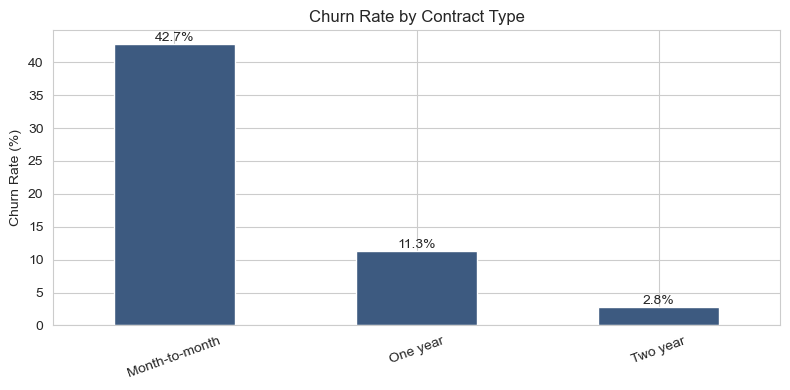

,customers,churn_rate
Contract,,
Month-to-month,3875,42.7
One year,1473,11.3
Two year,1695,2.8


In [9]:
# 1. Churn by contract type — the flexibility to leave matters
churn_rate_by("Contract", "Churn Rate by Contract Type")

**Insight:** Month-to-month customers churn at ~43% — about **14x** the two-year contract
rate (~3%). Contract type is clearly the strongest churn signal.

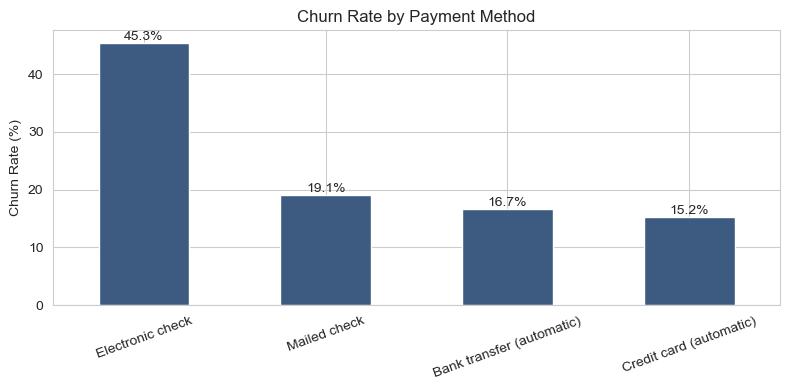

,customers,churn_rate
PaymentMethod,,
Electronic check,2365,45.3
Mailed check,1612,19.1
Bank transfer (automatic),1544,16.7
Credit card (automatic),1522,15.2


In [10]:
# 2. Churn by payment method
churn_rate_by("PaymentMethod", "Churn Rate by Payment Method")

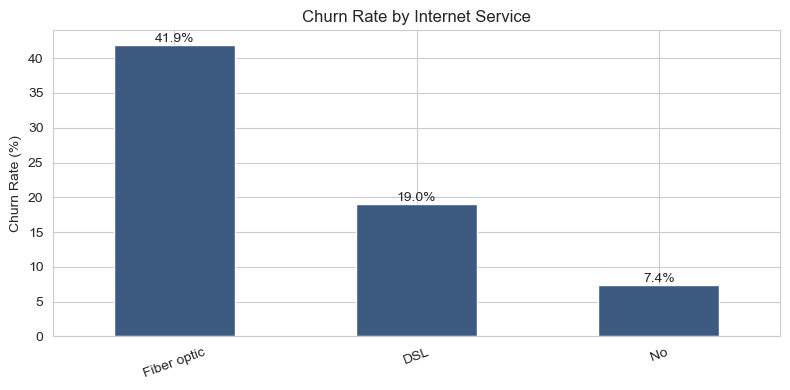

,customers,churn_rate
InternetService,,
Fiber optic,3096,41.9
DSL,2421,19.0
No,1526,7.4


In [11]:
# 3. Churn by internet service
churn_rate_by("InternetService", "Churn Rate by Internet Service")

**Insights:** Electronic check payers churn at ~45% — far above every auto-pay method.
Fiber optic customers churn at roughly **double** the DSL rate, suggesting a price or
service-quality problem despite fiber being the premium product.

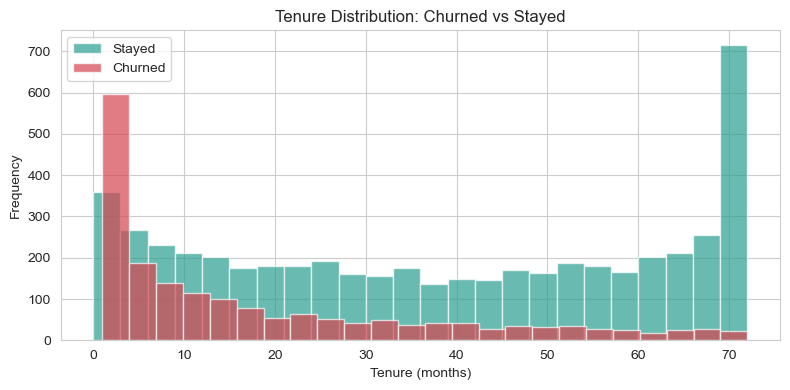

Average tenure — Stayed:  37.6 months
Average tenure — Churned: 18.0 months


In [12]:
# 4. Churn by tenure — when in the customer lifecycle do we lose people?
fig, ax = plt.subplots()
df[df["Churn"] == "No"]["tenure"].plot(kind="hist", bins=24, alpha=0.7,
                                       color="#2A9D8F", label="Stayed", ax=ax)
df[df["Churn"] == "Yes"]["tenure"].plot(kind="hist", bins=24, alpha=0.7,
                                        color="#D64550", label="Churned", ax=ax)
ax.set_title("Tenure Distribution: Churned vs Stayed")
ax.set_xlabel("Tenure (months)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Average tenure — Stayed:  {df[df['Churn']=='No']['tenure'].mean():.1f} months")
print(f"Average tenure — Churned: {df[df['Churn']=='Yes']['tenure'].mean():.1f} months")

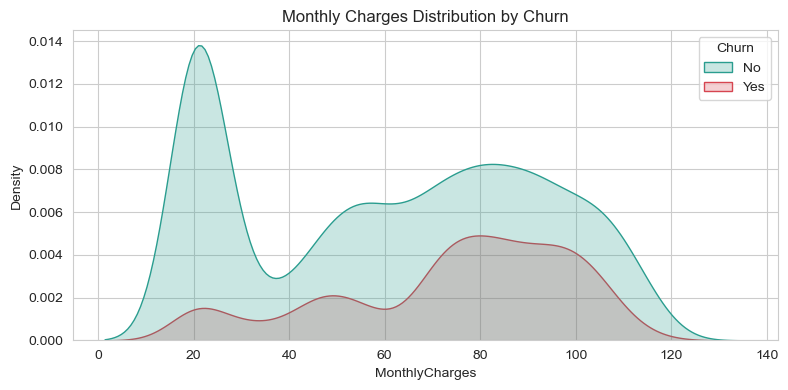

Average monthly charges — Stayed:  $61.27
Average monthly charges — Churned: $74.44


In [13]:
# 5. Churn by monthly charges — do bigger bills push people away?
fig, ax = plt.subplots()
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True,
            palette={"No": "#2A9D8F", "Yes": "#D64550"}, ax=ax)
ax.set_title("Monthly Charges Distribution by Churn")
plt.tight_layout()
plt.show()

print(f"Average monthly charges — Stayed:  ${df[df['Churn']=='No']['MonthlyCharges'].mean():.2f}")
print(f"Average monthly charges — Churned: ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.2f}")

**Insights:** Churners leave *early* — average tenure of churned customers is ~18 months
vs ~38 for loyal ones. Churners also pay **more per month** on average (~$74 vs ~$61):
high-bill customers are more price-sensitive.

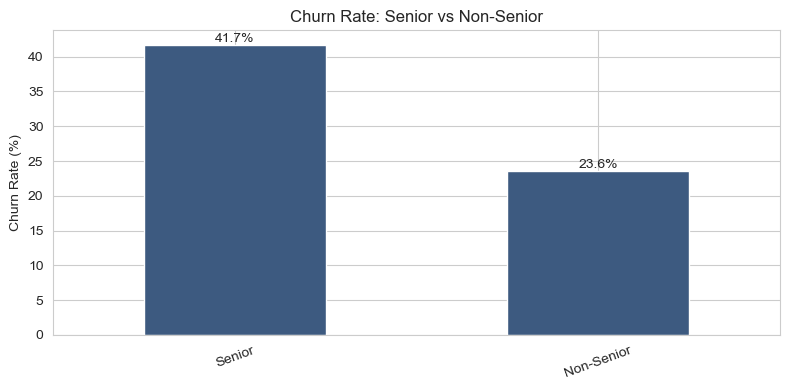

,customers,churn_rate
SeniorLabel,,
Senior,1142,41.7
Non-Senior,5901,23.6


In [14]:
# 6. Churn by senior citizen
df["SeniorLabel"] = np.where(df["SeniorCitizen"] == 1, "Senior", "Non-Senior")
churn_rate_by("SeniorLabel", "Churn Rate: Senior vs Non-Senior")

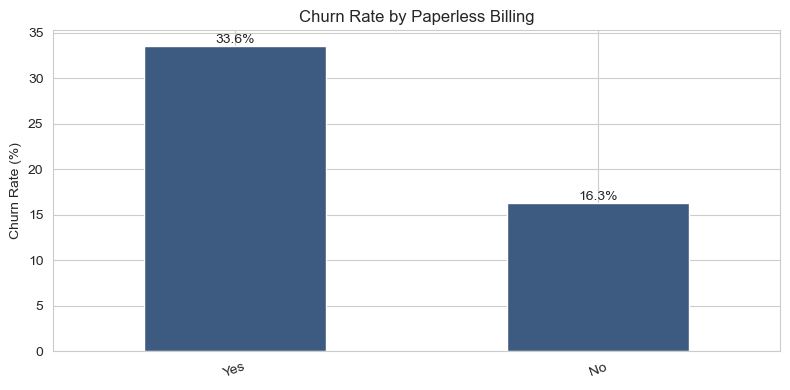

,customers,churn_rate
PaperlessBilling,,
Yes,4171,33.6
No,2872,16.3


In [15]:
# 7. Churn by paperless billing
churn_rate_by("PaperlessBilling", "Churn Rate by Paperless Billing")

**Insights:** Seniors churn at a noticeably higher rate (~42% vs ~24%), and paperless-billing
customers churn more too — likely because paperless billing correlates with the young,
month-to-month, fiber-optic customer profile.

## F. Feature Engineering

We create business-friendly columns. These make SQL analysis and the Power BI dashboard
much easier to read (e.g., "0-12 months" instead of raw tenure numbers).

| New column | Meaning |
|---|---|
| `TenureGroup` | Customer lifecycle stage (0-12 / 13-24 / 25-48 / 49-72 months) |
| `MonthlyChargeGroup` | Bill size bucket (Low / Medium / High) |
| `TotalChargeGroup` | Lifetime spend quartile |
| `CustomerValueSegment` | High/Medium/Low value (bill size + loyalty combined) |

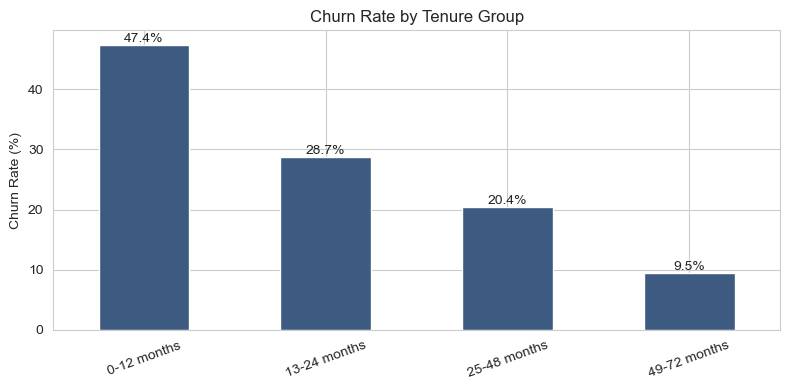

,customers,churn_rate
TenureGroup,,
0-12 months,2186,47.4
13-24 months,1024,28.7
25-48 months,1594,20.4
49-72 months,2239,9.5


In [16]:
# TenureGroup — lifecycle stage
df["TenureGroup"] = pd.cut(df["tenure"], bins=[-1, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"])

# MonthlyChargeGroup — bill size bucket
df["MonthlyChargeGroup"] = pd.cut(df["MonthlyCharges"], bins=[0, 35, 70, 200],
    labels=["Low (<$35)", "Medium ($35-$70)", "High (>$70)"])

# TotalChargeGroup — lifetime spend quartiles
df["TotalChargeGroup"] = pd.qcut(df["TotalCharges"], q=4,
    labels=["Q1 Lowest Spend", "Q2", "Q3", "Q4 Highest Spend"])

# CustomerValueSegment — combines bill size and loyalty
def value_segment(row):
    if row["MonthlyCharges"] >= 70 and row["tenure"] >= 24:
        return "High Value"
    elif row["MonthlyCharges"] >= 70 or row["tenure"] >= 24:
        return "Medium Value"
    return "Low Value"

df["CustomerValueSegment"] = df.apply(value_segment, axis=1)

# Quick check: churn rate by the new groups
churn_rate_by("TenureGroup", "Churn Rate by Tenure Group")

In [17]:
# Save the cleaned + engineered dataset for SQL and the scripts
df_clean = df.drop(columns=["SeniorLabel"])  # helper column, not needed in the file
df_clean.to_csv("../data/processed/cleaned_customer_churn.csv", index=False)
print(f"Cleaned dataset saved: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")

Cleaned dataset saved: 7,043 rows x 26 columns


## G. Preprocessing — Building a Leakage-Free Pipeline

Machine learning models need numbers, not text. We build a **pipeline** that:
- **One-hot encodes** categorical columns (e.g. `Contract` becomes 3 columns of 0/1)
- **Standard-scales** numeric columns (mean 0, std 1 — helps Logistic Regression)

**Why a pipeline?** The scaler and encoder are fitted **only on training data**, then
applied to test data. Fitting them on all data first would leak information from the
test set into training — a classic beginner mistake called **data leakage**.

**What we exclude from features:**
- `customerID` — just a label
- `Churn` / `ChurnFlag` — that's the answer!
- Engineered group columns — they duplicate `tenure`/`MonthlyCharges` (they're for BI, not the model)

In [18]:
NUMERIC_FEATURES = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
CATEGORICAL_FEATURES = ["gender", "Partner", "Dependents", "PhoneService",
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod"]

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df["ChurnFlag"]

# Preprocessor: scale numbers, one-hot encode categories
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
])

# 80/20 split; stratify=y keeps the churn % identical in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print(f"Training set: {X_train.shape[0]:,} customers")
print(f"Test set:     {X_test.shape[0]:,} customers")
print(f"Churn rate — train: {y_train.mean():.1%} | test: {y_test.mean():.1%}")

Training set: 5,634 customers
Test set:     1,409 customers
Churn rate — train: 26.5% | test: 26.5%


## H. Train and Compare 3 Models

We train three classic classifiers. All use `class_weight="balanced"` so they pay extra
attention to the minority class (churners).

For each model we report **Accuracy, Precision, Recall, F1** — measured on the
**churn class**, because that's the class we care about:
- **Precision:** of customers we *flagged* as churners, how many really churned?
- **Recall:** of customers who *really* churned, how many did we catch?

In [19]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000,
        class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=6,
        class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=10,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
}

results, trained = [], {}

for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    trained[name] = pipe

    results.append({
        "Model": name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision (Churn)": precision_score(y_test, y_pred),
        "Recall (Churn)":    recall_score(y_test, y_pred),
        "F1-Score (Churn)":  f1_score(y_test, y_pred),
    })

    print(f"===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=["Stayed", "Churned"]))

results_df = pd.DataFrame(results).round(4)
results_df

===== Logistic Regression =====
              precision    recall  f1-score   support

      Stayed       0.90      0.72      0.80      1035
     Churned       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

===== Decision Tree =====
              precision    recall  f1-score   support

      Stayed       0.90      0.72      0.80      1035
     Churned       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



===== Random Forest =====
              precision    recall  f1-score   support

      Stayed       0.88      0.79      0.84      1035
     Churned       0.55      0.71      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.77      0.78      1409



,Model,Accuracy,Precision (Churn),Recall (Churn),F1-Score (Churn)
0,Logistic Regression,0.7381,0.5043,0.7834,0.6136
1,Decision Tree,0.7402,0.5069,0.7888,0.6172
2,Random Forest,0.7700,0.5521,0.7086,0.6206


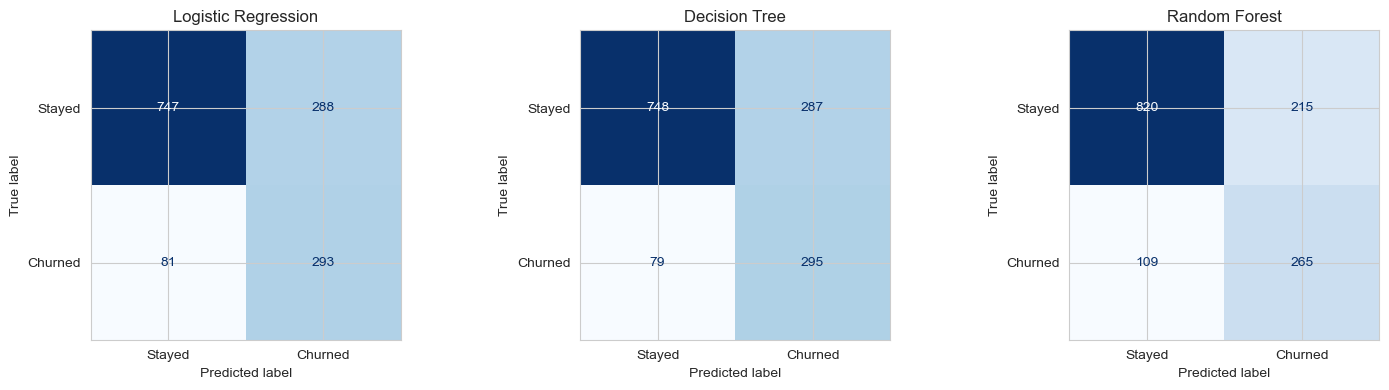

In [20]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pipe) in zip(axes, trained.items()):
    ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test,
        display_labels=["Stayed", "Churned"], cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.show()

## I. Model Selection — Think Business, Not Just Accuracy

**Why not just pick the highest accuracy?** Because the two mistakes cost very different
amounts:

| Mistake | What happens | Cost |
|---|---|---|
| **False negative** (missed churner) | Customer leaves silently | Lose ~$65-100/month + reacquisition cost |
| **False positive** (false alarm) | Loyal customer gets a retention offer | A small discount, maybe unnecessary |

Missing a churner is far more expensive, so we select the model with the **highest recall
on the churn class** (F1 as tie-breaker so we don't pick a model that flags everyone).

In [21]:
# Pick best model: highest churn recall, F1 as tie-breaker
ranked = results_df.sort_values(["Recall (Churn)", "F1-Score (Churn)"],
                                ascending=False)
best_name = ranked.iloc[0]["Model"]
best_pipe = trained[best_name]

print(f"Selected model: {best_name}")
print(f"  Churn recall:  {ranked.iloc[0]['Recall (Churn)']:.1%} of real churners caught")
print(f"  Churn F1:      {ranked.iloc[0]['F1-Score (Churn)']:.4f}")

# Save the comparison table for the README / documentation
perf = results_df.copy()
perf["Selected"] = np.where(perf["Model"] == best_name, "Yes", "No")
perf.to_csv("../outputs/model_performance.csv", index=False)
print("\nSaved: outputs/model_performance.csv")

Selected model: Decision Tree
  Churn recall:  78.9% of real churners caught
  Churn F1:      0.6172

Saved: outputs/model_performance.csv


## J. Feature Importance — What Drives Churn?

We extract how much each feature influenced the model. For Logistic Regression we use the
absolute coefficient size (on standardized features); tree models have built-in importances.

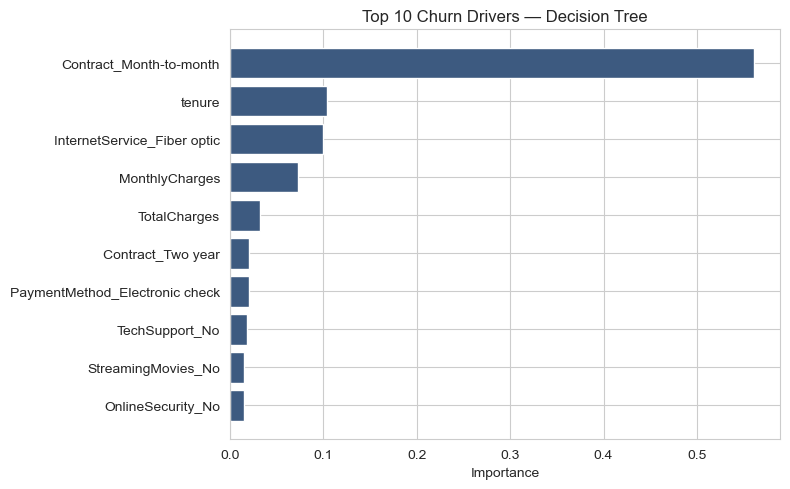

,Feature,Importance,Model
0,Contract_Month-to-month,0.560884,Decision Tree
1,tenure,0.104477,Decision Tree
2,InternetService_Fiber optic,0.099554,Decision Tree
3,MonthlyCharges,0.072766,Decision Tree
4,TotalCharges,0.031771,Decision Tree
5,Contract_Two year,0.020974,Decision Tree
6,PaymentMethod_Electronic check,0.019974,Decision Tree
7,TechSupport_No,0.017933,Decision Tree
8,StreamingMovies_No,0.015087,Decision Tree
9,OnlineSecurity_No,0.014890,Decision Tree


In [22]:
prep = best_pipe.named_steps["preprocessor"]
mdl = best_pipe.named_steps["model"]
feature_names = prep.get_feature_names_out()

if hasattr(mdl, "feature_importances_"):
    importance = mdl.feature_importances_          # tree-based
else:
    importance = np.abs(mdl.coef_[0])              # logistic regression

fi = pd.DataFrame({"Feature": feature_names, "Importance": importance})
fi["Feature"] = fi["Feature"].str.replace("num__", "").str.replace("cat__", "")
fi = fi.sort_values("Importance", ascending=False).reset_index(drop=True)
fi["Model"] = best_name
fi.to_csv("../outputs/feature_importance.csv", index=False)

# Plot the top 10 drivers
top10 = fi.head(10).iloc[::-1]
plt.figure(figsize=(8, 5))
plt.barh(top10["Feature"], top10["Importance"], color="#3D5A80")
plt.title(f"Top 10 Churn Drivers — {best_name}")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

fi.head(10)

## K. Final Prediction Output for Power BI

We score **every customer** with a churn probability and translate it into an
action-oriented **Risk Level**:

| Risk level | Probability | Action |
|---|---|---|
| High | ≥ 60% | Retention team calls this week |
| Medium | 30-59% | Automated loyalty offer |
| Low | < 30% | Business as usual |

In [23]:
churn_probability = best_pipe.predict_proba(X)[:, 1]
predicted = best_pipe.predict(X)

def risk_level(p):
    if p >= 0.60: return "High"
    if p >= 0.30: return "Medium"
    return "Low"

predictions = pd.DataFrame({
    "customerID": df["customerID"],
    "Actual_Churn": df["Churn"],
    "Predicted_Churn": np.where(predicted == 1, "Yes", "No"),
    "Churn_Probability": churn_probability.round(4),
    "Risk_Level": [risk_level(p) for p in churn_probability],
    "Contract": df["Contract"],
    "PaymentMethod": df["PaymentMethod"],
    "InternetService": df["InternetService"],
    "tenure": df["tenure"],
    "MonthlyCharges": df["MonthlyCharges"],
    "TotalCharges": df["TotalCharges"],
    "TenureGroup": df["TenureGroup"],
    "MonthlyChargeGroup": df["MonthlyChargeGroup"],
    "CustomerValueSegment": df["CustomerValueSegment"],
})

# Export for analysis and for Power BI
predictions.to_csv("../outputs/churn_predictions.csv", index=False)
predictions.to_csv("../data/powerbi/churn_predictions_powerbi.csv", index=False)

print("Saved: outputs/churn_predictions.csv")
print("Saved: data/powerbi/churn_predictions_powerbi.csv")
print("\nRisk level breakdown:")
print(predictions["Risk_Level"].value_counts())

# Headline business number: monthly revenue at risk
at_risk = predictions[(predictions["Predicted_Churn"] == "Yes") &
                      (predictions["Actual_Churn"] == "No")]
print(f"\nActive customers predicted to churn: {len(at_risk):,}")
print(f"Estimated monthly revenue at risk: ${at_risk['MonthlyCharges'].sum():,.0f}")

predictions.head()

Saved: outputs/churn_predictions.csv
Saved: data/powerbi/churn_predictions_powerbi.csv

Risk level breakdown:
Risk_Level
Low       3315
High      2453
Medium    1275
Name: count, dtype: int64

Active customers predicted to churn: 1,432
Estimated monthly revenue at risk: $110,234


,customerID,Actual_Churn,Predicted_Churn,Churn_Probability,Risk_Level,Contract,PaymentMethod,InternetService,tenure,MonthlyCharges,TotalCharges,TenureGroup,MonthlyChargeGroup,CustomerValueSegment
0,7590-VHVEG,No,Yes,0.7527,High,Month-to-month,Electronic check,DSL,1,29.85,29.85,0-12 months,Low (<$35),Low Value
1,5575-GNVDE,No,No,0.0462,Low,One year,Mailed check,DSL,34,56.95,1889.50,25-48 months,Medium ($35-$70),Medium Value
2,3668-QPYBK,Yes,Yes,0.7527,High,Month-to-month,Mailed check,DSL,2,53.85,108.15,0-12 months,Medium ($35-$70),Low Value
3,7795-CFOCW,No,No,0.0462,Low,One year,Bank transfer (automatic),DSL,45,42.30,1840.75,25-48 months,Medium ($35-$70),Medium Value
4,9237-HQITU,Yes,Yes,0.7643,High,Month-to-month,Electronic check,Fiber optic,2,70.70,151.65,0-12 months,High (>$70),Medium Value


## L. Save the Trained Model

`joblib` saves the **entire pipeline** (preprocessing + model) as one file, so scoring new
customers later takes two lines: `load` then `predict`.

In [24]:
joblib.dump(best_pipe, "../outputs/churn_prediction_model.pkl")
print("Model saved: outputs/churn_prediction_model.pkl")

# Demo: reload and score one customer to prove it works
reloaded = joblib.load("../outputs/churn_prediction_model.pkl")
sample = X.iloc[[0]]
print(f"\nSample customer churn probability: {reloaded.predict_proba(sample)[0, 1]:.1%}")

Model saved: outputs/churn_prediction_model.pkl

Sample customer churn probability: 75.3%


## Conclusion

**What we built:** a complete churn prediction pipeline — from raw CSV to customer-level
risk scores feeding a Power BI dashboard.

**Key findings:**
1. **Contract type** is the strongest churn driver — month-to-month customers churn ~14x
   more than two-year contract customers.
2. **New customers churn most** — nearly half of churn happens in the first 12 months.
3. **Fiber optic** and **electronic check** customers churn well above average.
4. Churners pay **more per month** on average — price sensitivity is real.

**Model choice:** we optimized for **recall on the churn class**, because missing a real
churner (lost revenue) costs far more than a false alarm (a small retention offer).

**Next steps:** the exported `churn_predictions_powerbi.csv` powers a 3-page Power BI
dashboard (see `powerbi/dashboard_build_guide.md`), and the SQL scripts in `sql/`
reproduce the analysis in a database.